<a href="https://colab.research.google.com/github/makkergauri/uttarakhand-landslide-risk/blob/main/06_study_area.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Cell 1 - Drive, Earth Engine, libraries
from google.colab import drive
drive.mount('/content/drive')
!pip install -q rasterio matplotlib-scalebar

import ee
ee.Authenticate()
ee.Initialize(project="landslide-uttarakhand78873")

import os
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
import matplotlib.pyplot as plt

base = "/content/drive/MyDrive/landslide_project"
sa = f"{base}/study_area"
os.makedirs(sa, exist_ok=True)   # boundary and river files for Figure 1 go here
print("ready")

Mounted at /content/drive


*** Earth Engine *** Share your feedback by taking our Annual Developer Satisfaction Survey: https://google.qualtrics.com/jfe/form/SV_9oS0DRcPvElRMNw?source=python


ready


In [3]:
# Cell 2 - boundaries, rivers and places for Figure 1

# 1) all land in the region, as plain grey shapes
# (GAUL 2025 has no country level, so I use states/provinces and will draw them without border lines)
region = ee.Geometry.Rectangle([66, 5, 99, 38])
land = (ee.FeatureCollection("FAO/GAUL/2025/level1").filterBounds(region)
        .map(lambda f: ee.Feature(f.geometry().simplify(5000).intersection(region, 1000))))
land_gdf = gpd.GeoDataFrame.from_features(land.getInfo()["features"], crs="EPSG:4326")
land_gdf.to_file(f"{sa}/region_land.geojson", driver="GeoJSON")
print("land units in the region:", len(land_gdf))

# 2) Uttarakhand's districts ("Uttarakh" so it doesn't also match Uttar Pradesh)
dists = (ee.FeatureCollection("FAO/GAUL/2025/level2")
         .filter(ee.Filter.eq("ISO3_CODE", "IND"))
         .filter(ee.Filter.stringContains("GAUL1_NAME", "Uttarakh"))
         .map(lambda f: f.simplify(200)))
dist_gdf = gpd.GeoDataFrame.from_features(dists.getInfo()["features"], crs="EPSG:4326")
dist_gdf = dist_gdf[["GAUL2_NAME", "geometry"]]
dist_gdf.to_file(f"{sa}/uttarakhand_districts.geojson", driver="GeoJSON")
print(f"\nUttarakhand districts found: {len(dist_gdf)} (expected 13)")
print(sorted(dist_gdf["GAUL2_NAME"]))

# 3) main rivers inside Rudraprayag (same HydroSHEDS dataset as my distance-to-river layer)
aoi = dists.filter(ee.Filter.stringContains("GAUL2_NAME", "Rudra")).geometry()
rivers = (ee.FeatureCollection("WWF/HydroSHEDS/v1/FreeFlowingRivers")
          .filterBounds(aoi)
          .filter(ee.Filter.gt("DIS_AV_CMS", 20))       # only the bigger rivers (average flow > 20 m³/s)
          .map(lambda f: f.intersection(aoi, 10)))
riv_gdf = gpd.GeoDataFrame.from_features(rivers.getInfo()["features"], crs="EPSG:4326")
riv_gdf = riv_gdf[["DIS_AV_CMS", "geometry"]]
riv_gdf.to_file(f"{sa}/rudraprayag_main_rivers.geojson", driver="GeoJSON")
print(f"\nmain river segments: {len(riv_gdf)}; flow range {riv_gdf['DIS_AV_CMS'].min():.0f}–{riv_gdf['DIS_AV_CMS'].max():.0f} m³/s")

# 4) key places - I should check each of these in Google Maps before trusting them
places = pd.DataFrame({
    "name": ["Rudraprayag", "Gaurikund", "Kedarnath"],
    "lat":  [30.2847, 30.6533, 30.7352],
    "lon":  [78.9812, 79.0250, 79.0669],
})
places_gdf = gpd.GeoDataFrame(places, geometry=gpd.points_from_xy(places["lon"], places["lat"]), crs="EPSG:4326")
rudra = dist_gdf[dist_gdf["GAUL2_NAME"].str.contains("Rudra")]
places_gdf["inside_district"] = places_gdf.within(rudra.geometry.iloc[0])
places_gdf.to_file(f"{sa}/places.geojson", driver="GeoJSON")
print()
print(places_gdf[["name", "lat", "lon", "inside_district"]].to_string(index=False))

land units in the region: 169

Uttarakhand districts found: 13 (expected 13)
['Almora', 'Bageshwar', 'Chamoli', 'Champawat', 'Dehradun', 'Haridwar', 'Nainital', 'Pauri Garhwal', 'Pithoragarh', 'Rudraprayag', 'Tehri Garhwal', 'Udham Singh Nagar', 'Uttarkashi']

main river segments: 26; flow range 30–312 m³/s

       name     lat     lon  inside_district
Rudraprayag 30.2847 78.9812             True
  Gaurikund 30.6533 79.0250             True
  Kedarnath 30.7352 79.0669             True


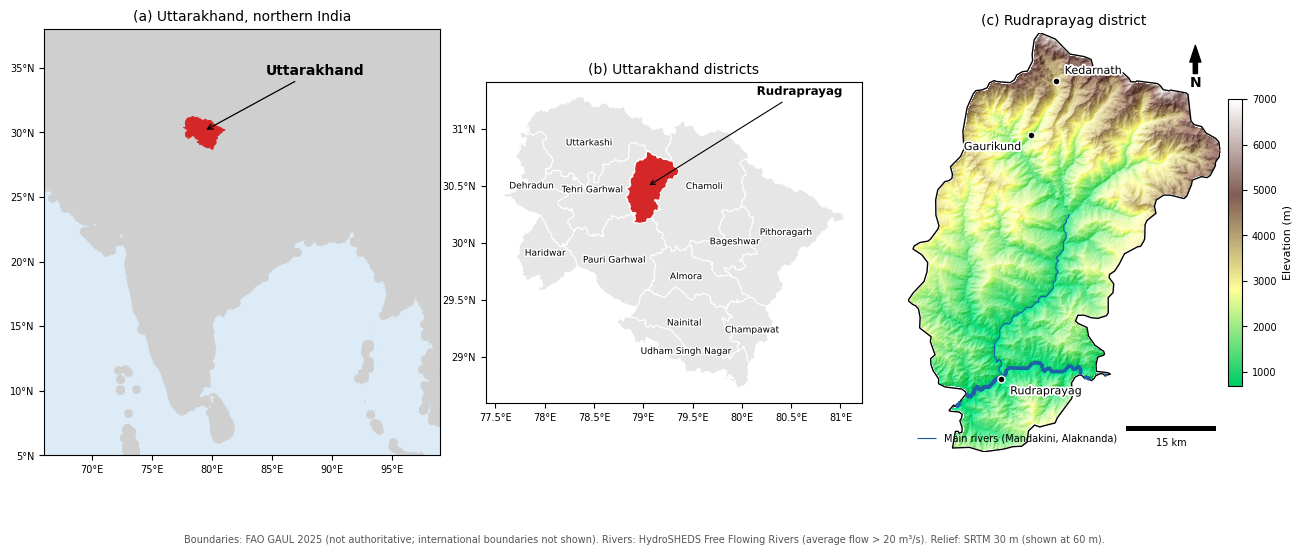

In [5]:
# Cell 3 - Figure 1: study area (South Asia -> Uttarakhand -> Rudraprayag)
from matplotlib.colors import LightSource, LinearSegmentedColormap, Normalize
from matplotlib.cm import ScalarMappable
import matplotlib.patheffects as pe
from matplotlib_scalebar.scalebar import ScaleBar

utk = dist_gdf.dissolve()                                  # Uttarakhand as one shape
rudra = dist_gdf[dist_gdf["GAUL2_NAME"].str.contains("Rudra")]

fig = plt.figure(figsize=(16, 6.2))
gs = fig.add_gridspec(1, 3, width_ratios=[1.05, 1, 1], wspace=0.12)
ax1, ax2, ax3 = fig.add_subplot(gs[0]), fig.add_subplot(gs[1]), fig.add_subplot(gs[2])

# (a) grey land, NO border lines (edge colour = fill colour hides the joins between units)
ax1.set_facecolor("#dcebf5")                               # sea
land_gdf.plot(ax=ax1, color="#cfcfcf", edgecolor="#cfcfcf", linewidth=0.3)
utk.plot(ax=ax1, color="#d62728", edgecolor="#d62728", linewidth=0.5)
ax1.annotate("Uttarakhand", xy=(79.3, 30.1), xytext=(84.5, 34.5), fontsize=10, fontweight="bold",
             arrowprops=dict(arrowstyle="->", lw=0.9))
ax1.set_xlim(66, 99); ax1.set_ylim(5, 38)
ax1.set_aspect(1 / np.cos(np.deg2rad(22)))                 # so shapes aren't squashed at this latitude
ax1.tick_params(labelsize=7)
ax1.set_title("(a) Uttarakhand, northern India", fontsize=10)

# (b) districts, Rudraprayag highlighted, every district labelled
dist_gdf.plot(ax=ax2, color="#e6e6e6", edgecolor="white", linewidth=0.8)
rudra.plot(ax=ax2, color="#d62728", edgecolor="white", linewidth=0.8)
for _, row in dist_gdf.iterrows():
    if "Rudra" in row["GAUL2_NAME"]:
        continue                                           # Rudraprayag gets its own label outside (below)
    p = row.geometry.representative_point()                # a point guaranteed to be inside the district
    ax2.text(p.x, p.y, row["GAUL2_NAME"], ha="center", va="center", fontsize=6.5,
             path_effects=[pe.withStroke(linewidth=2, foreground="white")])

# Rudraprayag is too small for its label, which covered Tehri Garhwal and Chamoli,
# so the label goes in the empty space to the north-east with an arrow
rp = rudra.geometry.iloc[0].representative_point()
ax2.annotate("Rudraprayag", xy=(rp.x, rp.y), xytext=(80.15, 31.3), fontsize=8.5, fontweight="bold",
             arrowprops=dict(arrowstyle="->", lw=0.8),
             path_effects=[pe.withStroke(linewidth=2.5, foreground="white")])
ax2.set_aspect(1 / np.cos(np.deg2rad(30)))
ax2.tick_params(labelsize=7)
ax2.set_title("(b) Uttarakhand districts", fontsize=10)

# (c) shaded relief coloured by elevation, rivers, places
with rasterio.open(f"{base}/rudraprayag_features.tif") as src:
    elev = src.read(1, out_shape=(src.height // 2, src.width // 2)).astype("float32")   # 60 m is plenty here
    b = src.bounds
cell = (b.right - b.left) / elev.shape[1]
outside = elev <= 0
elev[outside] = np.nan
filled = np.where(outside, np.nanmin(elev), elev)          # hillshading can't handle NaN
# terrain colours without the "sea blue" start: green valleys -> brown -> white peaks
cmap = LinearSegmentedColormap.from_list("land", plt.cm.terrain(np.linspace(0.25, 1, 256)))
norm = Normalize(vmin=700, vmax=7000)
ls = LightSource(azdeg=315, altdeg=45)
rgb = ls.shade(filled, cmap=cmap, norm=norm, blend_mode="soft", vert_exag=1, dx=cell, dy=cell)
rgb[outside, 3] = 0                                        # transparent outside the district
ax3.imshow(rgb, extent=(b.left, b.right, b.bottom, b.top))

rudra.to_crs("EPSG:32644").boundary.plot(ax=ax3, color="black", linewidth=1)
riv = riv_gdf.to_crs("EPSG:32644")
riv.plot(ax=ax3, color="#1f5fa8",
         linewidth=0.6 + 2.4 * riv["DIS_AV_CMS"] / riv["DIS_AV_CMS"].max(),   # thicker = more water
         label="Main rivers (Mandakini, Alaknanda)")

pl = places_gdf.to_crs("EPSG:32644")
offsets = {"Rudraprayag": (1500, -2500, "left"), "Gaurikund": (-1500, -2500, "right"),
           "Kedarnath": (1500, 1200, "left")}
for _, row in pl.iterrows():
    dx, dy, ha = offsets[row["name"]]
    ax3.plot(row.geometry.x, row.geometry.y, "o", ms=5, mfc="black", mec="white", mew=1, zorder=5)
    ax3.text(row.geometry.x + dx, row.geometry.y + dy, row["name"], fontsize=8, ha=ha, zorder=6,
             path_effects=[pe.withStroke(linewidth=2.5, foreground="white")])

ax3.add_artist(ScaleBar(1, "m", location="lower right", length_fraction=0.3, box_alpha=0.8,
                        font_properties={"size": 7}))
ax3.annotate("N", xy=(0.92, 0.97), xytext=(0.92, 0.87), xycoords="axes fraction", ha="center",
             fontsize=10, fontweight="bold", arrowprops=dict(facecolor="black", width=3, headwidth=8))
ax3.legend(loc="lower left", fontsize=7, frameon=False)
ax3.set_axis_off()
ax3.set_title("(c) Rudraprayag district", fontsize=10)
cb = fig.colorbar(ScalarMappable(norm=norm, cmap=cmap), ax=ax3, shrink=0.6, pad=0.02)
cb.set_label("Elevation (m)", fontsize=8)
cb.ax.tick_params(labelsize=7)

# degree units on the axis numbers, so 75 reads as 75°E
from matplotlib.ticker import FuncFormatter
for ax in (ax1, ax2):
    ax.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:g}°E"))
    ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:g}°N"))

fig.text(0.5, 0.01, "Boundaries: FAO GAUL 2025 (not authoritative; international boundaries not shown). "
         "Rivers: HydroSHEDS Free Flowing Rivers (average flow > 20 m³/s). Relief: SRTM 30 m (shown at 60 m).",
         ha="center", fontsize=7, color="#555555")

plt.savefig(f"{base}/figures/fig1_study_area.png", dpi=300, bbox_inches="tight")
plt.savefig(f"{base}/figures/fig1_study_area.pdf", bbox_inches="tight")
plt.show()